In [1]:
!pip install sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

import re
import string
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("complaint.csv")

In [4]:
df.head()

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  162421 non-null  int64 
 1   product     162421 non-null  object
 2   narrative   162411 non-null  object
dtypes: int64(1), object(2)
memory usage: 3.7+ MB


In [6]:
df.columns

Index(['Unnamed: 0', 'product', 'narrative'], dtype='object')

In [7]:
df = df[['narrative', 'product']]

In [8]:
df.columns = ['text', 'label']

In [9]:
df.head()

,text,label
0,purchase order day shipping amount receive pro...,credit_card
1,forwarded message date tue subject please inve...,credit_card
2,forwarded message cc sent friday pdt subject f...,retail_banking
3,payment history missing credit report speciali...,credit_reporting
4,payment history missing credit report made mis...,credit_reporting


In [10]:
df.dropna(inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 162411 entries, 0 to 162420
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    162411 non-null  object
 1   label   162411 non-null  object
dtypes: object(2)
memory usage: 3.7+ MB


In [12]:
import re
import string

def clean(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"\d+", "", text)

    text = re.sub(r"[^\w\s]", "", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [13]:
df["clean"] = df["text"].apply(clean)

In [14]:
df[["text","clean"]].head()

,text,clean
0,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...
1,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...
2,forwarded message cc sent friday pdt subject f...,forwarded message cc sent friday pdt subject f...
3,payment history missing credit report speciali...,payment history missing credit report speciali...
4,payment history missing credit report made mis...,payment history missing credit report made mis...


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

In [16]:
X = tfidf.fit_transform(df["clean"])

y = df["label"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, n_jobs=-1)

In [19]:
pred_lr = lr.predict(X_test)

In [20]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

print("===== Logistic Regression =====")

print("Accuracy :", accuracy_score(y_test, pred_lr))

===== Logistic Regression =====
Accuracy : 0.875658036511406


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_lr))

                     precision    recall  f1-score   support

        credit_card       0.80      0.79      0.79      3113
   credit_reporting       0.91      0.94      0.92     18235
    debt_collection       0.81      0.73      0.77      4630
mortgages_and_loans       0.85      0.83      0.84      3798
     retail_banking       0.88      0.88      0.88      2707

           accuracy                           0.88     32483
          macro avg       0.85      0.83      0.84     32483
       weighted avg       0.87      0.88      0.87     32483



In [23]:
print(classification_report(y_test, pred_nb))

                     precision    recall  f1-score   support

        credit_card       0.75      0.72      0.73      3113
   credit_reporting       0.87      0.92      0.90     18235
    debt_collection       0.82      0.60      0.69      4630
mortgages_and_loans       0.77      0.85      0.81      3798
     retail_banking       0.85      0.84      0.84      2707

           accuracy                           0.84     32483
          macro avg       0.81      0.79      0.80     32483
       weighted avg       0.84      0.84      0.84     32483



In [24]:
print("Jumlah Data :", len(df))

Jumlah Data : 162411


In [25]:
print("Jumlah Kategori :", df['label'].nunique())

Jumlah Kategori : 5


In [26]:
print(df['label'].unique())

['credit_card' 'retail_banking' 'credit_reporting' 'mortgages_and_loans'
 'debt_collection']


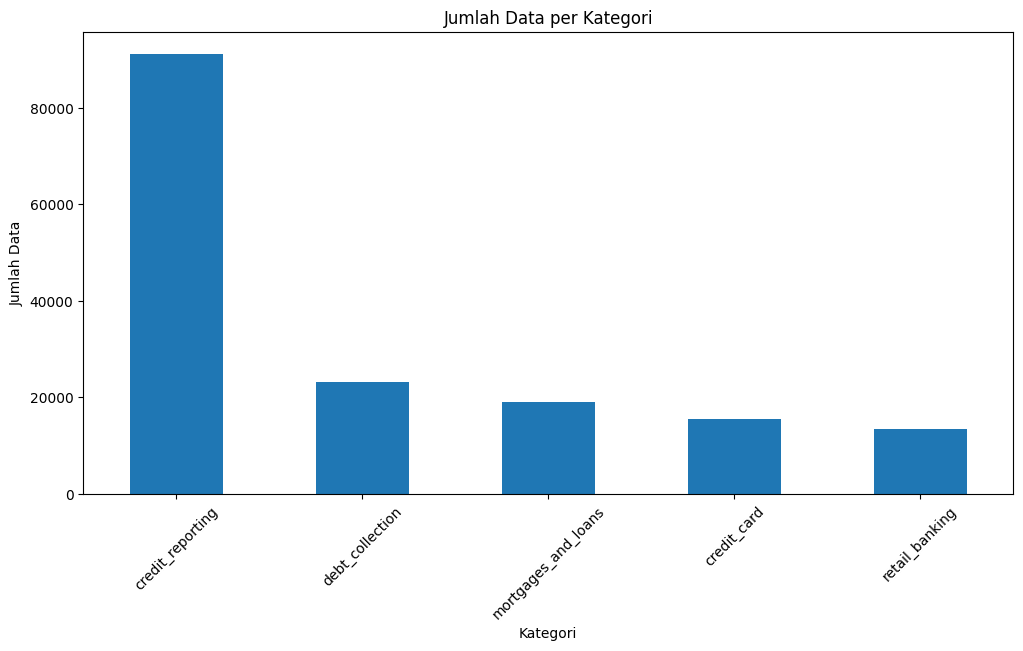

In [27]:
plt.figure(figsize=(12,6))

df['label'].value_counts().plot(kind='bar')

plt.title("Jumlah Data per Kategori")

plt.xlabel("Kategori")

plt.ylabel("Jumlah Data")

plt.xticks(rotation=45)

plt.show()

In [28]:
df["length"] = df["clean"].apply(len)

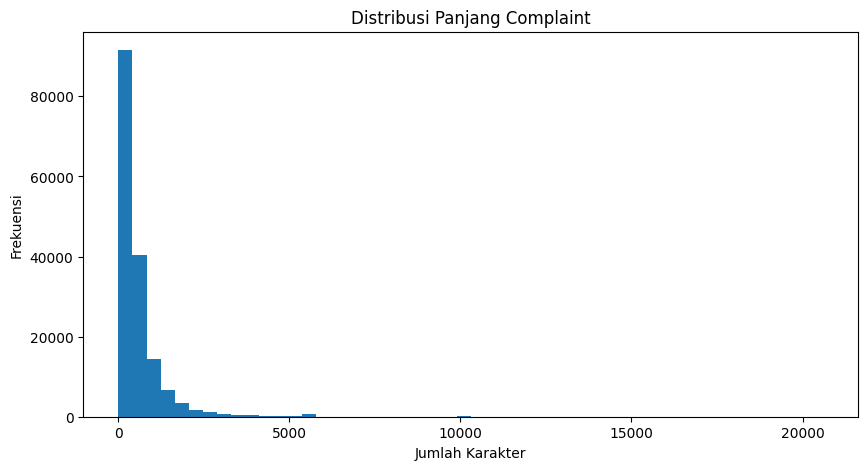

In [29]:
plt.figure(figsize=(10,5))

plt.hist(df["length"], bins=50)

plt.title("Distribusi Panjang Complaint")

plt.xlabel("Jumlah Karakter")

plt.ylabel("Frekuensi")

plt.show()

In [30]:
!pip install wordcloud

In [31]:
from wordcloud import WordCloud

In [32]:
text = " ".join(df["clean"])

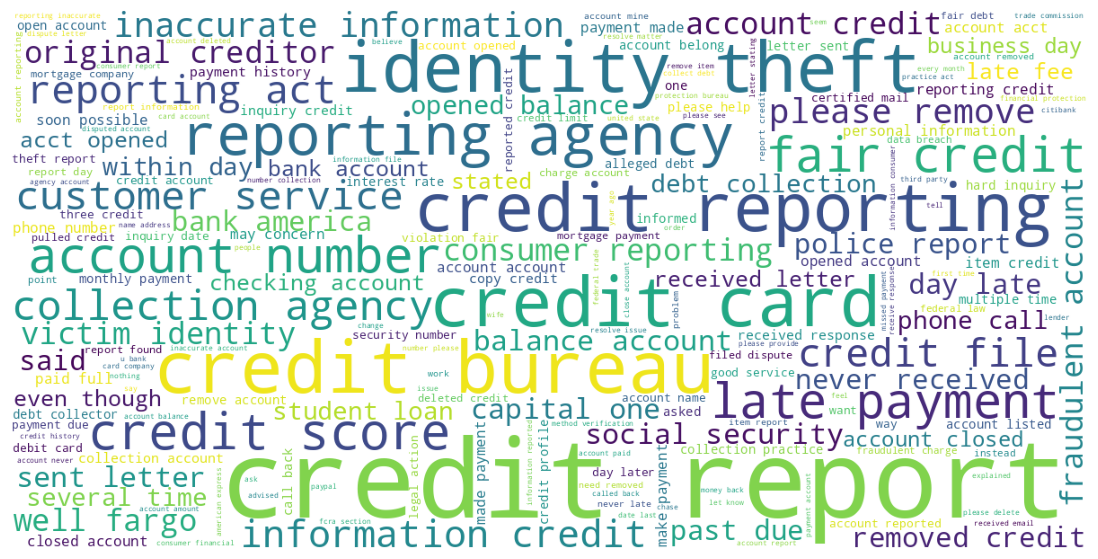

In [33]:
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wc)

plt.axis("off")

plt.show()

In [34]:
lr = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [35]:
print("Accuracy")

print(accuracy_score(y_test,pred_lr))

Accuracy
0.875658036511406


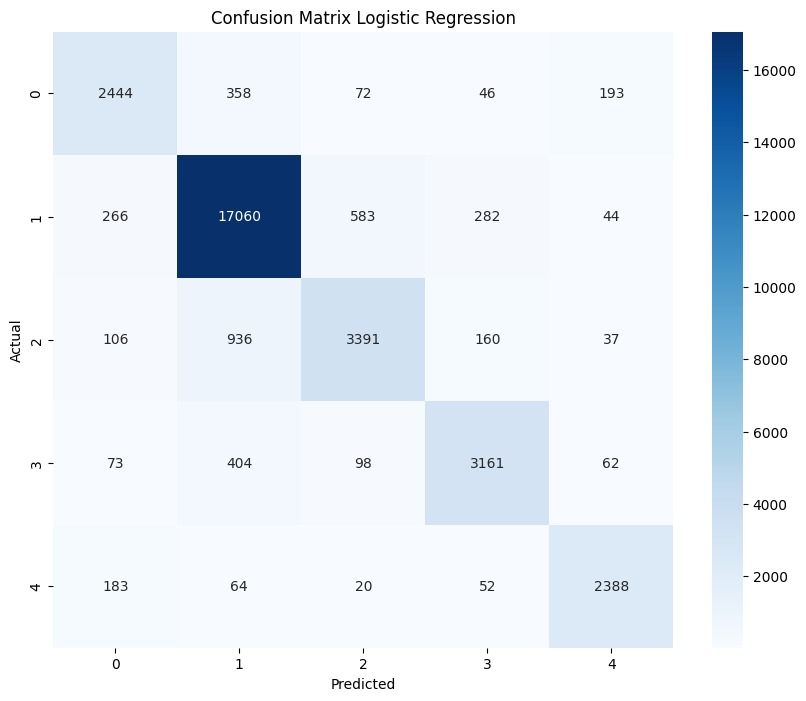

In [36]:
cm = confusion_matrix(y_test,pred_lr)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix Logistic Regression")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [37]:
nb = MultinomialNB()

nb.fit(X_train,y_train)

pred_nb = nb.predict(X_test)

In [38]:
print(accuracy_score(y_test,pred_nb))

0.8405935412369547


In [39]:
print(classification_report(y_test,pred_nb))

                     precision    recall  f1-score   support

        credit_card       0.75      0.72      0.73      3113
   credit_reporting       0.87      0.92      0.90     18235
    debt_collection       0.82      0.60      0.69      4630
mortgages_and_loans       0.77      0.85      0.81      3798
     retail_banking       0.85      0.84      0.84      2707

           accuracy                           0.84     32483
          macro avg       0.81      0.79      0.80     32483
       weighted avg       0.84      0.84      0.84     32483



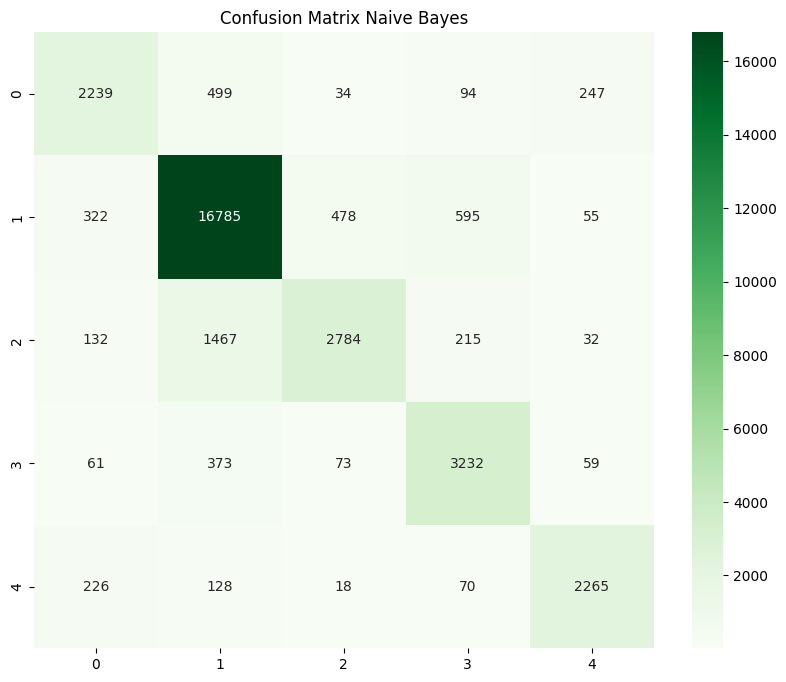

In [40]:
cm2 = confusion_matrix(y_test,pred_nb)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Confusion Matrix Naive Bayes")

plt.show()

In [41]:
acc_lr = accuracy_score(y_test,pred_lr)

acc_nb = accuracy_score(y_test,pred_nb)

In [42]:
model = [
    "Logistic Regression",
    "Naive Bayes"
]

accuracy = [
    acc_lr,
    acc_nb
]

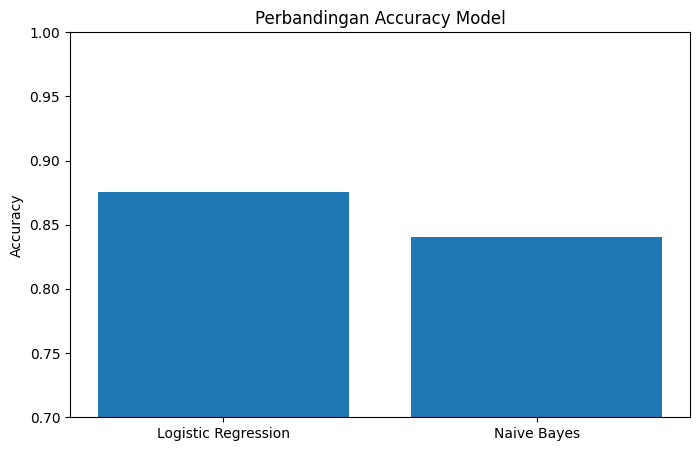

In [43]:
plt.figure(figsize=(8,5))

plt.bar(model,accuracy)

plt.ylim(0.7,1)

plt.title("Perbandingan Accuracy Model")

plt.ylabel("Accuracy")

plt.show()

In [44]:
import pickle

pickle.dump(
    lr,
    open("model.pkl","wb")
)

pickle.dump(
    tfidf,
    open("vectorizer.pkl","wb")
)

Kesimpulan

1. Logistic Regression memperoleh akurasi lebih tinggi dibandingkan Naive Bayes.
2. TF-IDF berhasil mengubah teks menjadi representasi numerik yang dapat diproses model machine learning.
3. Model mampu mengklasifikasikan keluhan pelanggan ke berbagai kategori produk perbankan.
4. Hasil evaluasi menggunakan Accuracy, Precision, Recall, dan F1-Score menunjukkan performa model yang baik.
5. Model kemudian disimpan sebagai file model.pkl untuk digunakan pada aplikasi Streamlit.